In [1]:
import CONSTANTS
from functions import *
import warnings
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from transformer_classes import *
from tqdm import tqdm
from sklearn.metrics import *

warnings.filterwarnings('ignore')

# Transformer

Objective: predict change in BTC price given features

## Prepare data
Create tupled dataset


In [2]:
RESPONSE = 'close'

In [3]:
data = pd.read_csv(f'../{fullDataPath('BTC')}')
daily_data = dataSetup(data, trainingColPath='../training_columns.txt')[-LIMIT:]
daily_data

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,close,gradient
time,,,,,,,,,,
2024-06-27,54298.361946,65288.365054,45.0,0.000000,10530.358988,-273098.307712,61499.718571,9207.959382,61615.39,798.71
2024-06-28,54145.327791,65688.441209,46.0,0.000000,11381.025874,-283628.666701,60846.397143,10270.673373,60313.35,-1302.04
2024-06-29,54049.203970,66151.516030,44.0,0.000000,3199.036501,-272247.640827,60321.551429,12652.300393,60885.67,572.32
2024-06-30,53659.403029,67123.510971,45.0,0.000000,4263.229248,-269048.604326,59944.277143,13116.627323,62668.26,1782.59
2024-07-01,53290.098982,67942.372018,49.0,0.000000,12326.706965,-264785.375077,58970.824286,13267.725496,62830.13,161.87
...,...,...,...,...,...,...,...,...,...,...
2025-06-22,101255.903690,110442.214310,40.0,3.116564,7872.258744,-15479.804635,104624.465714,0.000000,100996.87,-1163.16
2025-06-23,101255.903690,110442.214310,37.0,-3.693263,8904.624392,-7607.545890,104624.465714,0.000000,105419.39,4422.52
2025-06-24,101255.903690,110442.214310,47.0,1.941039,5773.171996,1297.078502,104624.465714,0.000000,106141.00,721.61


<Axes: title={'center': 'BTC Price'}, xlabel='Date', ylabel='Price (USD)'>

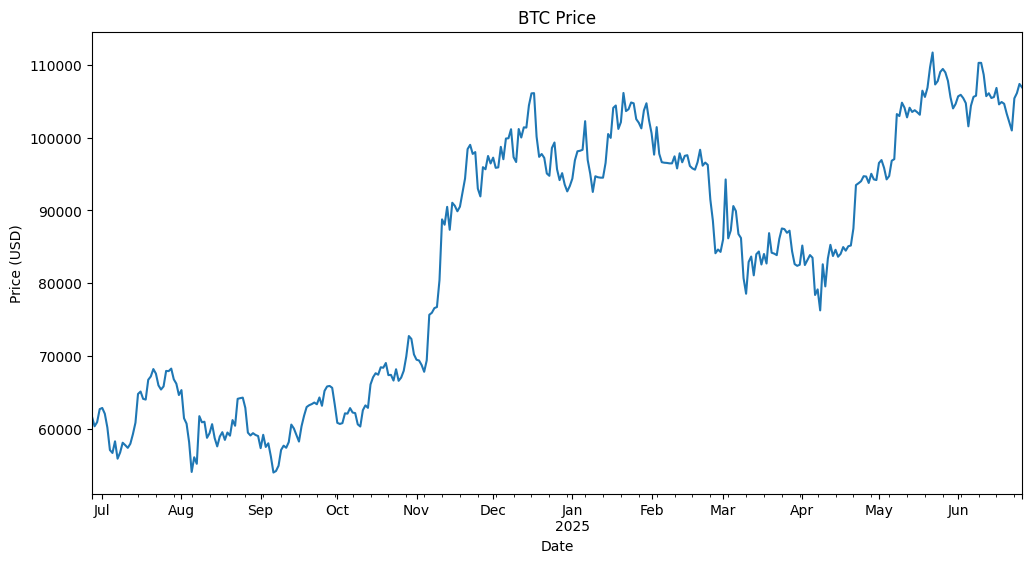

In [4]:
daily_data[RESPONSE].plot.line(title=f'{COIN} Price', figsize=(12, 6), ylabel='Price (USD)', xlabel='Date')

<Axes: ylabel='Frequency'>

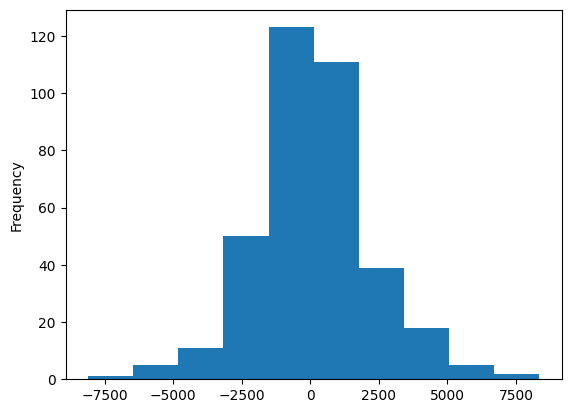

In [5]:
daily_data['gradient'].plot.hist()

In [6]:
daily_data[RESPONSE].describe()

count       365.000000
mean      83544.245562
std       17509.746977
min       53950.010000
25%       65088.990000
50%       86877.960000
75%       97862.530000
max      111722.530000
Name: close, dtype: float64

# Load the Transformer Model

Sequence the data to make it predict the next price

## Preprocess the data


In [7]:
daily_data = transformerDataSetup(daily_data)
daily_data[['sequence', 'next']]

,sequence,next
time,,
2024-06-27,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[61615.39, 60313.35, 60885.67, 62668.26, 62830..."
2024-06-28,"[61615.39, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[60313.35, 60885.67, 62668.26, 62830.13, 62040..."
2024-06-29,"[61615.39, 60313.35, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[60885.67, 62668.26, 62830.13, 62040.22, 60145..."
2024-06-30,"[61615.39, 60313.35, 60885.67, 0, 0, 0, 0, 0, ...","[62668.26, 62830.13, 62040.22, 60145.01, 57042..."
2024-07-01,"[61615.39, 60313.35, 60885.67, 62668.26, 0, 0,...","[62830.13, 62040.22, 60145.01, 57042.14, 56639..."
...,...,...
2025-06-22,"[61615.39, 60313.35, 60885.67, 62668.26, 62830...","[100996.87, 105419.39, 106141.0, 107400.22, 10..."
2025-06-23,"[61615.39, 60313.35, 60885.67, 62668.26, 62830...","[105419.39, 106141.0, 107400.22, 107400.22, 10..."
2025-06-24,"[61615.39, 60313.35, 60885.67, 62668.26, 62830...","[106141.0, 107400.22, 107400.22, 107400.22, 10..."


## Load the Model

### Data Setup

In [8]:
from sklearn.preprocessing import StandardScaler
DAYS_TO_PREDICT = TEST_DAYS
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(daily_data, testSize=len(daily_data)-DAYS_TO_PREDICT)
X_train_norm, X_test_norm, y_train_norm, y_test_norm, sequence_scaler, target_scaler = normalize(X_train, X_test, y_train, y_test)
training_cols = trainingCols('../training_columns.txt')

train_stuff = daily_data.loc[X_train_norm.index, training_cols]
test_stuff = daily_data.loc[X_test_norm.index, training_cols]
X_train_norm = pd.concat([X_train_norm, train_stuff], axis=1)
X_test_norm = pd.concat([X_test_norm, test_stuff], axis=1)

In [9]:
model = torch.load(f'../models/{COIN}_model2.pth')

In [10]:
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
import CONSTANTS
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from functions import *
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.mask_value = CONSTANTS.FILL

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (mask should be boolean: True=valid, False=masked)
        if mask is not None:
            # Expand mask to match attention scores dimensions
            if len(mask.shape) == 2:  # (batch_size, seq_length)
                mask = mask.unsqueeze(1).unsqueeze(1)  # (batch_size, 1, 1, seq_length)
                mask = mask.expand(-1, -1, attn_scores.size(-2), -1)

            # Apply mask: False positions get -1e9
            attn_scores = attn_scores.masked_fill(~mask, self.mask_value)  # Note the ~ (NOT operator)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, -1, self.d_model)

        output = self.W_o(attn_output)
        return output


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(FeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout):
        super(TransformerEncoder, self).__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return x


class BaseTransformer(nn.Module):
    def __init__(self, d_model=512, num_heads=8, num_layers=6,
                 d_ff=2048, max_seq_length=5000, dropout=0.1, output_dim=TEST_DAYS,
                 learning_rate=1e-4, batch_size=32, mask_value=0.0):
        super(BaseTransformer, self).__init__()

        self.d_model = d_model
        self.mask_value = mask_value  # Value to mask (0.0 for padding)
        self.input_projection = None
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        self.transformer_encoder = TransformerEncoder(
            num_layers, d_model, num_heads, d_ff, dropout
        )
        self.output_dim = output_dim
        self.output_projection = nn.Linear(d_model, output_dim)
        self.dropout = nn.Dropout(dropout)

        # Training parameters
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(self.device)
        self.history = {'loss': []}

    def create_padding_mask(self, x):
        """Create mask for padded positions (True = valid, False = padded)"""
        # x shape: (batch_size, seq_length) or (batch_size, seq_length, features)
        if len(x.shape) == 3:
            # For 3D input, check if entire feature vector is zeros
            mask = (x != self.mask_value).any(dim=-1)  # (batch_size, seq_length)
        else:
            # For 2D input
            mask = (x != self.mask_value)  # (batch_size, seq_length)

        return mask

    def _create_input_projection(self, input_dim):
        """Create input projection layer based on data dimensions"""
        if self.input_projection is None:
            self.input_projection = nn.Linear(input_dim, self.d_model).to(self.device)

    def forward(self, x, mask=None):
        # x shape: (batch_size, seq_length, input_dim) or (batch_size, seq_length)

        # Handle 2D input (batch_size, seq_length) by adding feature dimension
        if len(x.shape) == 2:
            x = x.unsqueeze(-1)  # (batch_size, seq_length, 1)

        # Create input projection if not exists
        if self.input_projection is None:
            self._create_input_projection(x.shape[-1])

        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.dropout(x)
        x = self.transformer_encoder(x, mask)
        x = x.mean(dim=1)

        # Output projection now returns (batch_size, 7) for 7-day prediction
        output = self.output_projection(x)  # (batch_size, 7)
        return output

    def _prepare_data(self, X, y):
        """Convert DataFrame with lists and Series to proper tensor format"""
        # Handle pandas DataFrame with lists in a single column
        if isinstance(X, pd.DataFrame):
            # Get the column name (assuming single column with lists)
            column_name = X.columns[0]

            # Extract the lists from the DataFrame column
            list_data = X[column_name].tolist()

            # Convert lists to numpy arrays and stack them
            # Each list becomes a sequence (row in the final array)
            sequences = []
            for seq in list_data:
                if isinstance(seq, list):
                    sequences.append(np.array(seq, dtype=np.float32))
                else:
                    # Handle case where it's already an array
                    sequences.append(np.array(seq, dtype=np.float32))

            # Stack all sequences into a 2D array: (num_samples, seq_length)
            X_array = np.stack(sequences)

            if len(X_array.shape) == 2:
                # X_array is (batch_size, seq_length) - add feature dimension
                X_array = X_array.reshape(X_array.shape[0], X_array.shape[1], 1)

        elif isinstance(X, pd.Series):
            # Handle Series with lists
            list_data = X.tolist()
            sequences = [np.array(seq, dtype=np.float32) for seq in list_data]
            X_array = np.stack(sequences)
            if len(X_array.shape) == 2:
                X_array = X_array.reshape(X_array.shape[0], X_array.shape[1], 1)
        else:
            # Handle other formats (numpy arrays, etc.)
            X_array = np.array(X)
            if len(X_array.shape) == 2:
                X_array = X_array.reshape(X_array.shape[0], X_array.shape[1], 1)

        # Handle y data - THIS IS THE NEW PART FOR SERIES OF LISTS
        if isinstance(y, pd.Series):
            # Check if the Series contains lists (for multi-output)
            if len(y) > 0 and isinstance(y.iloc[0], list):
                # Convert Series of lists to 2D numpy array
                y_list_data = y.tolist()
                y_array = np.array(y_list_data, dtype=np.float32)  # Shape: (n_samples, 7)
            else:
                # Regular Series with single values
                y_array = y.values
                # Ensure y is 2D: (batch_size, output_dim)
                if len(y_array.shape) == 1:
                    y_array = y_array.reshape(-1, 1)
        else:
            y_array = np.array(y)
            # Ensure y is 2D: (batch_size, output_dim)
            if len(y_array.shape) == 1:
                y_array = y_array.reshape(-1, 1)

        # Convert to tensors
        X_tensor = torch.FloatTensor(X_array).to(self.device)
        y_tensor = torch.FloatTensor(y_array).to(self.device)
        return X_tensor, y_tensor

    def fit(self, X_train, y_train, epochs=100, validation_data=None, verbose=True):
        """
        Train the transformer model

        Args:
            X_train: pandas DataFrame with a single column containing lists
            y_train: pandas Series with target values
            epochs: Number of training epochs
            validation_data: Tuple of (X_val, y_val) for validation
            verbose: Whether to print training progress
        """
        # Prepare data
        X_tensor, y_tensor = self._prepare_data(X_train, y_train)
        self.sequence_length = X_tensor.shape[1]

        if verbose:
            print(f"Data shapes - X: {X_tensor.shape}, y: {y_tensor.shape}")
            if isinstance(X_train, pd.DataFrame):
                print(f"DataFrame column: {X_train.columns[0]}")
                print(f"Sample sequence length: {len(X_train.iloc[0, 0])}")

        # Create dataset and dataloader
        train_dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        # Setup optimizer and loss function
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        criterion = nn.MSELoss()

        # Validation data preparation
        val_loader = None
        if validation_data is not None:
            X_val, y_val = validation_data
            X_val_tensor, y_val_tensor = self._prepare_data(X_val, y_val)
            val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        # Training loop
        self.train()
        trainLosses = []
        validationLosses = []
        for epoch in tqdm(range(epochs), desc="Training Progress", disable=not verbose):
            total_loss = 0
            num_batches = 0

            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()

                # Forward pass
                outputs = self(batch_X)
                loss = criterion(outputs, batch_y)

                # Backward pass
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                num_batches += 1

            avg_loss = total_loss / num_batches
            self.history['loss'].append(avg_loss)

            # Validation
            val_loss = None
            if val_loader is not None:
                val_loss = self._validate(val_loader, criterion)
                if 'val_loss' not in self.history:
                    self.history['val_loss'] = []
                self.history['val_loss'].append(val_loss)

            # early stopping if validation loss
            trainLosses.append(avg_loss)
            validationLosses.append(val_loss)

        if verbose:
            print("Training completed!")

        # make a plot of the training and validation losses

        plt.figure(figsize=(10, 5))
        plt.plot(trainLosses, label='Training Loss')
        if val_loader is not None:
            plt.plot(validationLosses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        return self

    def _validate(self, val_loader, criterion):
        """Compute validation loss"""
        self.eval()
        total_val_loss = 0
        num_batches = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = self(batch_X)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()
                num_batches += 1

        self.train()
        return total_val_loss / num_batches

    def predict(self, X, scaler=None):
        """Make predictions on new data"""
        self.eval()

        # Create dummy y for _prepare_data consistency
        if isinstance(X, pd.DataFrame):
            dummy_y = pd.Series([0] * len(X))
        else:
            dummy_y = np.zeros(len(X))

        X_tensor, _ = self._prepare_data(X, dummy_y)

        with torch.no_grad():
            predictions = self(X_tensor)

        value = predictions.cpu().numpy()
        if scaler is not None:
            value = scaler.inverse_transform(value)
        return value

    def predict_value(self, starter, scaler=None):
        new = starter
        new, next = sequence(new, len(new) - 1)
        new = pd.DataFrame({'sequences': [new]})
        if scaler:
            new = pd.DataFrame({
                'sequences': normalize_sequences(new.iloc[:, 0], scaler)
            })
        else:
            new = pd.DataFrame({'sequences': [new]})
        return self.predict(new, scaler)[0, 0]


    def score(self, X, y):
        """Calculate R² score"""
        predictions = self.predict(X)

        # Handle pandas Series
        if isinstance(y, pd.Series):
            y_true = y.values.reshape(-1, 1)
        else:
            y_true = np.array(y).reshape(-1, 1)

        ss_res = np.sum((y_true - predictions) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

    def rmse(self, X, y):
        """Calculate RMSE"""
        predictions = self.predict(X)

        # Handle pandas Series
        if isinstance(y, pd.Series):
            y_true = y.values.reshape(-1, 1)
        else:
            y_true = np.array(y).reshape(-1, 1)

        return np.sqrt(np.mean((y_true - predictions) ** 2))

    def tune_hyperparameters(self, X_train, y_train, param_grid, cv=5,
                             scoring='r2', n_jobs=-1, verbose=True, epochs=50):
        """
        Tune BaseTransformer hyperparameters using GridSearchCV [[1]]

        Args:
            X_train: Training data (pandas DataFrame with sequences)
            y_train: Training targets (pandas Series)
            param_grid: Dictionary of hyperparameters to search
            cv: Number of cross-validation folds
            scoring: Scoring metric ('r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error')
            n_jobs: Number of parallel jobs (-1 for all processors)
            verbose: Whether to print progress
            epochs: Number of training epochs per model

        Returns:
            GridSearchCV object with results
        """

        # Default parameter grid if none provided [[2]]
        if param_grid is None:
            param_grid = {
                'd_model': [128, 256, 512],  # Model dimension [[2]]
                'num_heads': [4, 8, 12],  # Number of attention heads [[2]]
                'num_layers': [2, 4, 6],  # Number of transformer layers [[2]]
                'd_ff': [512, 1024, 2048],  # Feed-forward dimension [[2]]
                'dropout': [0.1, 0.2, 0.3],  # Dropout rate [[2]]
                'learning_rate': [1e-4, 5e-4, 1e-3],  # Learning rate [[2]]
                'batch_size': [16, 32, 64]  # Batch size [[2]]
            }

        # Create the wrapper estimator
        estimator = BaseTransformerWrapper(epochs=epochs, verbose=False)

        # Set up cross-validation strategy [[1]]
        if isinstance(cv, int):
            cv_strategy = KFold(n_splits=cv, shuffle=True, random_state=42)
        else:
            cv_strategy = cv

        # Validate scoring parameter [[3]]
        scoring_functions = {
            'r2': 'r2',
            'neg_mean_squared_error': 'neg_mean_squared_error',
            'neg_root_mean_squared_error': 'neg_root_mean_squared_error'
        }

        if scoring not in scoring_functions:
            raise ValueError(f"Scoring must be one of {list(scoring_functions.keys())}")

        # Initialize GridSearchCV [[1]]
        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring=scoring_functions[scoring],
            n_jobs=n_jobs,
            verbose=2 if verbose else 0,
            return_train_score=True,
            error_score='raise'
        )

        if verbose:
            print("Starting Grid Search Cross-Validation...")
            # Calculate total combinations
            total_combinations = 1
            for param_values in param_grid.values():
                total_combinations *= len(param_values)
            print(f"Parameter combinations to test: {total_combinations}")
            print(f"Total fits: {total_combinations * cv}")

        # Fit the grid search [[1]]
        try:
            grid_search.fit(X_train, y_train)
        except Exception as e:
            print(f"Grid search failed with error: {e}")
            return None

        if verbose:
            print("\nGrid Search completed!")
            print(f"Best parameters: {grid_search.best_params_}")
            print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

        # Store results in the instance for later access
        self.grid_search_results_ = grid_search
        self.best_params_ = grid_search.best_params_
        self.best_score_ = grid_search.best_score_

        return grid_search

    def analyze_tuning_results(self, top_n=5):
        """
        Analyze and display grid search results

        Args:
            top_n: Number of top results to display

        Returns:
            DataFrame with detailed results
        """
        if not hasattr(self, 'grid_search_results_'):
            raise ValueError("No grid search results found. Run tune_hyperparameters first.")

        grid_search = self.grid_search_results_

        # Convert results to DataFrame [[3]]
        results_df = pd.DataFrame(grid_search.cv_results_)

        # Select relevant columns
        columns_of_interest = [
            'mean_test_score', 'std_test_score', 'rank_test_score',
            'mean_train_score', 'std_train_score'
        ]

        # Add parameter columns
        param_columns = [col for col in results_df.columns if col.startswith('param_')]
        columns_of_interest.extend(param_columns)

        # Filter and sort results
        results_summary = results_df[columns_of_interest].copy()
        results_summary = results_summary.sort_values('rank_test_score')

        print(f"\nTop {top_n} parameter combinations:")
        print("=" * 80)

        for i in range(min(top_n, len(results_summary))):
            row = results_summary.iloc[i]
            print(f"\nRank {int(row['rank_test_score'])}:")
            print(f"  CV Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
            print(f"  Train Score: {row['mean_train_score']:.4f} (±{row['std_train_score']:.4f})")
            print("  Parameters:")
            for col in param_columns:
                param_name = col.replace('param_', '')
                print(f"    {param_name}: {row[col]}")

        return results_summary

    def create_tuned_model(self, **override_params):
        """
        Create a new BaseTransformer with optimized hyperparameters

        Args:
            **override_params: Additional parameters to override

        Returns:
            BaseTransformer instance with optimized hyperparameters
        """
        if not hasattr(self, 'best_params_'):
            raise ValueError("No tuning results found. Run tune_hyperparameters first.")

        best_params = self.best_params_.copy()
        best_params.update(override_params)

        # Remove epochs from params as it's not a BaseTransformer parameter
        epochs = best_params.pop('epochs', 100)

        return BaseTransformer(**best_params)

    def quick_tune(self, X_train, y_train, cv=3, epochs=30):
        """
        Quick hyperparameter tuning with a smaller parameter grid [[2]]
        Suitable for initial exploration or when computational resources are limited
        """
        # Smaller parameter grid for faster execution [[2]]
        quick_param_grid = {
            'd_model': [128, 256],
            'num_heads': [4, 8],
            'num_layers': [2, 4],
            'dropout': [0.1, 0.2],
            'learning_rate': [1e-4, 5e-4],
            'batch_size': [32, 64]
        }

        return self.tune_hyperparameters(
            X_train, y_train,
            param_grid=quick_param_grid,
            cv=cv,
            epochs=epochs,
            verbose=True
        )


class BaseTransformerWrapper(BaseEstimator, RegressorMixin):
    """Scikit-learn compatible wrapper for BaseTransformer"""

    def __init__(self, d_model=512, num_heads=8, num_layers=6, d_ff=2048,
                 dropout=0.1, learning_rate=1e-4, batch_size=32, epochs=50,
                 output_dim=1, max_seq_length=5000, mask_value=0.0, verbose=False):
        self.d_model = d_model
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.d_ff = d_ff
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.output_dim = output_dim
        self.max_seq_length = max_seq_length
        self.mask_value = mask_value
        self.verbose = verbose
        self.model_ = None

    def fit(self, X, y):
        """Fit the BaseTransformer model"""
        # Initialize the model with current hyperparameters
        self.model_ = BaseTransformer(
            d_model=self.d_model,
            num_heads=self.num_heads,
            num_layers=self.num_layers,
            d_ff=self.d_ff,
            dropout=self.dropout,
            learning_rate=self.learning_rate,
            batch_size=self.batch_size,
            output_dim=self.output_dim,
            max_seq_length=self.max_seq_length,
            mask_value=self.mask_value
        )

        # Train the model
        self.model_.fit(X, y, epochs=self.epochs, verbose=self.verbose)
        return self

    def predict(self, X):
        """Make predictions using the trained model"""
        if self.model_ is None:
            raise ValueError("Model must be fitted before making predictions")
        return self.model_.predict(X).flatten()

    def score(self, X, y):
        """Return R² score for regression tasks"""
        if self.model_ is None:
            raise ValueError("Model must be fitted before scoring")
        return self.model_.score(X, y)

Data shapes - X: torch.Size([358, 365, 1]), y: torch.Size([358, 7])
DataFrame column: sequences
Sample sequence length: 365


Training Progress: 100%|██████████| 5/5 [00:53<00:00, 10.75s/it]

Training completed!


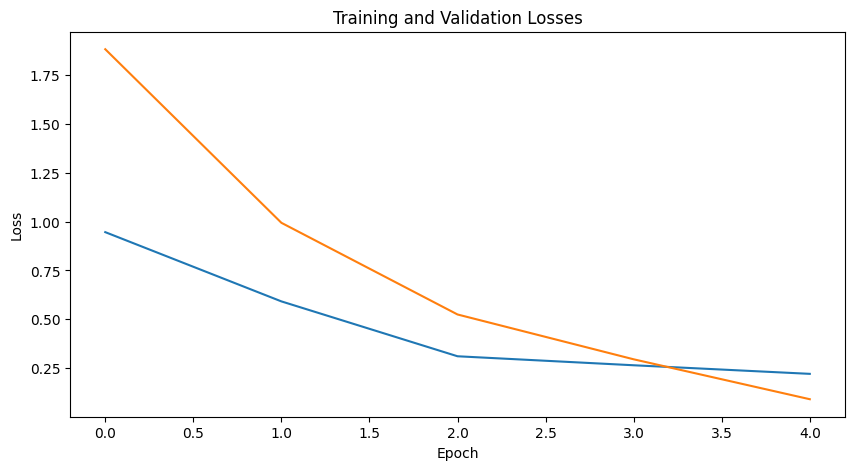

In [12]:
# Create model with appropriate settings for Bitcoin prediction
model = BaseTransformer(
    d_model=128,
    num_heads=8,
    num_layers=4,
    output_dim=7,  # Add this line - this is crucial!
    learning_rate=1e-4,
    batch_size=32,
    dropout=0.1,
    mask_value=FILL
)
model.fit(X_train_norm, y_train_norm, epochs=5, validation_data=(X_test_norm, y_test_norm))
torch.save(model, f'../models/{COIN}_model.pth')

In [13]:
model = torch.load(f'../models/{COIN}_full_model.pth')

predictions = model.predict(X_test_norm)
predictions = target_scaler.inverse_transform(predictions).reshape(-1)
predictions = pd.Series(predictions, index=y_test.index)
y_test_norm.index = X_test_norm.index
predictions

time
2025-06-20    99852.468750
2025-06-21    99535.593750
2025-06-22    98947.820312
2025-06-23    97997.773438
2025-06-24    96369.226562
2025-06-25    93593.312500
2025-06-26    88598.234375
dtype: float32

In [14]:
diff = predictions - y_test
plt.axhline(0.0, color='r', linestyle='--')
diff.plot.line(title='Difference on Prediction and Actual')

TypeError: unsupported operand type(s) for -: 'float' and 'list'

time
2025-06-20    [103317.8, 102160.03, 100996.87, 105419.39, 10...
2025-06-21    [102160.03, 100996.87, 105419.39, 106141.0, 10...
2025-06-22    [100996.87, 105419.39, 106141.0, 107400.22, 10...
2025-06-23    [105419.39, 106141.0, 107400.22, 107400.22, 10...
2025-06-24    [106141.0, 107400.22, 107400.22, 107400.22, 10...
2025-06-25    [107400.22, 107400.22, 107400.22, 107400.22, 1...
2025-06-26    [106935.95, 106935.95, 106935.95, 106935.95, 1...
Name: next, dtype: object

<Axes: title={'center': 'Predicted vs. Actual Value on Validation Month'}, xlabel='Date', ylabel='Price'>

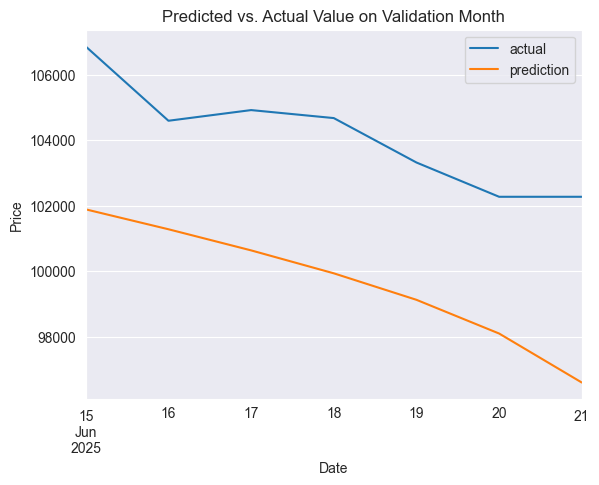

In [21]:
comparison = pd.concat([y_test, predictions], axis=1)
comparison.columns = ['actual', 'prediction']
comparison.plot.line(title='Predicted vs. Actual Value on Validation Month', xlabel='Date', ylabel='Price')

In [33]:
new = daily_data[RESPONSE].iloc[-30:]
new, next = sequence(new, len(new)-1)
new = pd.DataFrame({'sequences': [new]})
new = pd.DataFrame({""
        'sequences': normalize_sequences(new.iloc[:, 0], sequence_scaler)
    })
model.predict(new, sequence_scaler)[0, 0]

106165.69

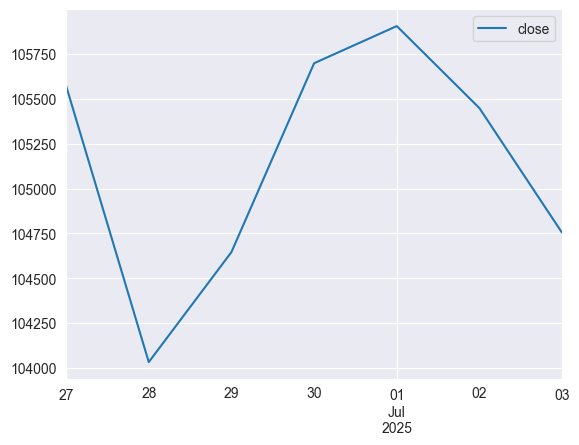

In [28]:
price = daily_data[RESPONSE].iloc[-1]
starter = daily_data[RESPONSE].iloc[-30:]
predictions = predict_sequence(model, price, starter, sequence_scaler, sequence_length=7)
new_days = pd.date_range(start=daily_data.index[-1] + pd.Timedelta(days=1), periods=len(predictions), freq='D')
predictions_df = pd.DataFrame(predictions, index=new_days, columns=[RESPONSE])
predictions_df.plot.line()
plt.show()

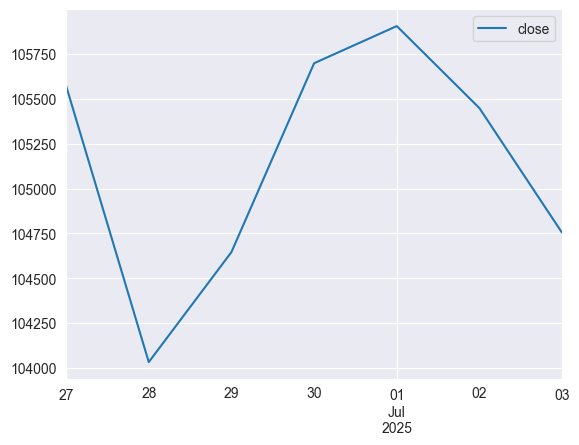

,close
2025-06-27,105572.58
2025-06-28,104033.26
2025-06-29,104645.87
2025-06-30,105697.94
2025-07-01,105904.94
2025-07-02,105447.82
2025-07-03,104753.38


In [32]:
predictNextNDaysTransformer(daily_data, total_length=365)